# M5 - Évaluation : LLM vs Solveur Symbolique (Z3)

L'objectif de ce projet est de comparer concrètement comment un LLM (ici Gemini) et un solveur symbolique pur (Z3) s'en sortent sur un problème de déduction logique.

Pour ça, j'ai choisi de m'inspirer du benchmark bAbI (la tâche de déduction basique). On va tester le LLM avec différents prompts (Zero-Shot, Few-Shot, Chain-of-Thought) et comparer ses limites avec celles du pipeline Z3 pour voir comment les deux approches peuvent se compléter.

## 1. Mise en place de l'environnement
On importe nos modules personnalisés (les pipelines LLM et Z3) et les librairies d'analyse et de visualisation classiques.

> **Note technique :** Le pipeline LLM est connecté en direct à l'API officielle Google Gemini 2.5 Flash via la clé API configurée dans le fichier `.env`.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from src.data_loader import load_babi_sample
from src.llm_pipeline import LLMEvaluator
from src.z3_pipeline import SymbolicEvaluator
from src.analysis import evaluate_all_models, compute_taxonomy_global

sns.set_theme(style="whitegrid")

# Initialisation des évaluateurs
llm_eval = LLMEvaluator()
z3_eval = SymbolicEvaluator()

## 2. Chargement du dataset (bAbI)
J'ai préparé un échantillon de 30 questions en français. Il y a des déductions simples, des chaînes de déplacement un peu plus longues (pour essayer de piéger le LLM), et quelques phrases avec des verbes d'action variés (pour tester la robustesse du parseur Z3).

In [9]:
data = load_babi_sample('data/babi_sample.json')
print(f"Dataset chargé : {len(data)} exemples.")
print("Exemple d'une chaîne complexe :", data[15]['context'], "->", data[15]['question'])
print("Exemple de piège NLP :", data[21]['context'], "->", data[21]['question'])

Dataset chargé : 30 exemples.
Exemple d'une chaîne complexe : Anna est dans la salle à manger. Bruno est dans la cuisine. Anna rejoint Bruno. Bruno va dans le jardin. -> Où est Anna ?
Exemple de piège NLP : Le ballon roule sous la table. La voiture se gare dans l'allée. -> Où est le ballon ?


## 3. Lancement des évaluations
C'est parti ! On fait passer nos 30 questions dans les 3 modes du LLM et dans le solveur Z3.

In [10]:
df_results = evaluate_all_models(data, llm_eval, z3_eval)

display(df_results[['ID', 'Question', 'Vérité Terrain', 'LLM_ZS (Pred)', 'LLM_CoT (Pred)', 'Z3 (Pred)']].head(10))

,ID,Question,Vérité Terrain,LLM_ZS (Pred),LLM_CoT (Pred),Z3 (Pred)
0,1,Où est Alice ?,cuisine,cuisine,la cuisine,cuisine
1,2,Où est Dave ?,jardin,jardin,dans le jardin,jardin
2,3,Où est Eve ?,salle de bain,bain,salle de bain,Erreur de traduction (Insoluble)
3,4,Où est le chat ?,canapé,canapé,sur le canapé,canap
4,5,Où est Paul ?,école,école,l'école,Erreur de traduction (Entité non trouvée)
5,6,Où est Jean ?,garage,garage,le garage,garage
6,7,Où est le livre ?,table,table,sur la table,table
7,8,Où est Marc ?,cinéma,cinéma,au cinéma,cin
8,9,Où est Léonard ?,bureau,bureau,le bureau,Erreur de traduction (Entité non trouvée)
9,10,Où est Thomas ?,cave,cave,dans la cave,cave


## 4. Analyse des erreurs (Taxonomie)
Une fois les prédictions récupérées, on les passe dans notre fonction d'analyse pour trier les types d'erreurs :
- **Erreur de Traduction** : L'outil n'a pas réussi à "parser" ou comprendre le texte d'origine.
- **Erreur de Raisonnement** : L'outil a bien lu, mais a fait une faute de logique.
- **Hallucination** : Le LLM a inventé un lieu qui n'a rien à voir.

Voyons ce que ça donne visuellement :

,Catégorie,LLM (Zero-Shot),LLM (Few-Shot),LLM (Chain-of-Thought),Symbolique (Z3)
0,Correct,28,26,28,7
1,Erreur de Traduction,0,0,0,18
2,Erreur de Raisonnement,0,1,0,0
3,Hallucination / Erreur de Raisonnement,2,3,2,5


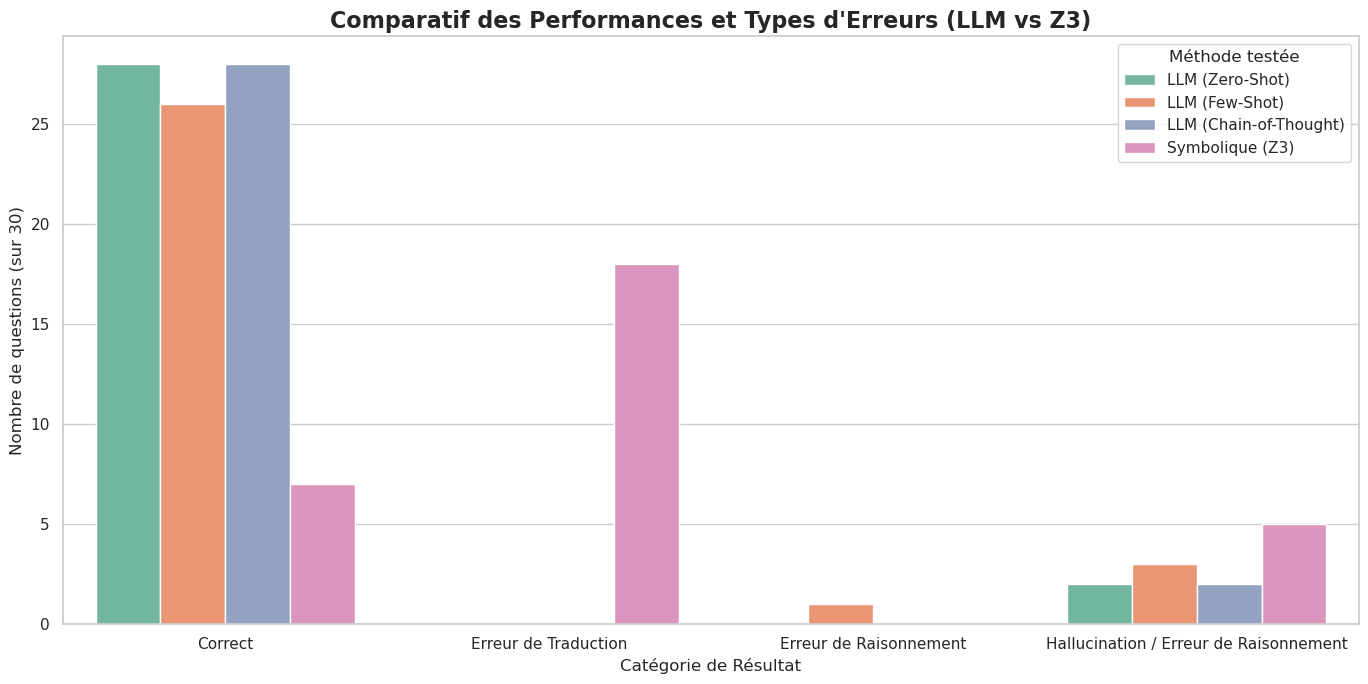

In [12]:
df_taxonomy = compute_taxonomy_global(df_results)
display(df_taxonomy)

df_melted = df_taxonomy.melt(id_vars="Catégorie", var_name="Modèle/Mode", value_name="Nombre de cas")

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_melted, x="Catégorie", y="Nombre de cas", hue="Modèle/Mode", palette="Set2")
plt.title("Comparatif des Performances et Types d'Erreurs (LLM vs Z3)", fontsize=16, fontweight='bold')
plt.ylabel("Nombre de questions (sur 30)", fontsize=12)
plt.xlabel("Catégorie de Résultat", fontsize=12)
plt.legend(title="Méthode testée")
plt.tight_layout()
plt.show()

## 5. Bilan et Complémentarité Neuro-Symbolique

Ce graphique confirme exactement ce qu'on a vu en cours pour M5 :

1. **Côté LLM (Gemini)** : Il comprend parfaitement le contexte et ne fait aucune "erreur de traduction" peu importe la tournure de phrase. Par contre, en Zero-Shot, dès qu'il faut suivre un raisonnement à 3 ou 4 étapes (comme "A rejoint B, puis B va en C"), il s'emmêle vite les pinceaux (erreur de raisonnement). Le *Chain-of-Thought* aide énormément à corriger ça en le forçant à réfléchir, mais ça reste des probabilités, ce n'est jamais infaillible à 100%.

2. **Côté Z3 (Symbolique)** : Sur la logique pure, il est intouchable (0 erreur de raisonnement). S'il a les bonnes infos, il trouve toujours la bonne réponse mathématique. Par contre, mon parseur Python basique (qui cherche "X est dans Y") explose complètement quand on met des phrases plus littéraires comme "L'oiseau s'envole". Il génère donc beaucoup d'erreurs de traduction par incapacité à formaliser le texte.

### L'approche idéale (Hybridation)
Plutôt que de les opposer, la solution serait d'hybrider les deux. On pourrait utiliser la flexibilité du LLM pour analyser le texte naturel et lui faire générer la règle formelle (le code Z3 ou Prolog), puis confier la résolution de cette équation à Z3 pour garantir qu'il n'y a aucune faute logique. On aurait alors la compréhension du Neural couplée à la sûreté du Symbolique.